# 第1周 Day2：手撕神经网络训练

> **学习目标**：从零实现一个简单的前馈神经网络，理解反向传播
>
> **参考资源**：
> - 课程: [吴恩达 Deep Learning - Neural Networks Basics](https://www.coursera.org/learn/neural-networks-deep-learning)
> - 课程: [李宏毅机器学习 - 深度学习入门](https://www.bilibili.com/video/BV1Wv411h7kN)
> - 教程: [Neural Networks from Scratch](https://www.youtube.com/playlist?list=PLQVvvvaa5QuCjyjbA3C8C2UEgC6w2OsiA)
> - 课程: [Andrej Karpathy: Neural Networks Zero to Hero](https://www.youtube.com/playlist?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ)

---

## 📋 环境准备（首次运行请先执行下方单元格）

In [25]:
import sys
print(f"Python 版本: {sys.version}")
print(f"Python 路径: {sys.executable}")

required = {'numpy', 'torch', 'matplotlib', 'ipykernel', 'sklearn'}
installed = set()
missing = set()

for pkg in required:
    try:
        __import__(pkg)
        installed.add(pkg)
    except ImportError:
        missing.add(pkg)

print(f"\n已安装: {installed}")
if missing:
    print(f"缺少: {missing}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + list(missing))
    print("安装完成！请重启内核后继续。")
else:
    print("所有依赖已就绪！")
    import numpy as np
    import torch
    import matplotlib
    import matplotlib.pyplot as plt
    from matplotlib.font_manager import FontProperties
    print(f"  numpy: {np.__version__}")
    print(f"  torch: {torch.__version__}")

    chinese_fonts = ["Microsoft YaHei", "SimHei", "SimSun", "FangSong", "KaiTi", "STSong", "STHeiti", "STFangsong"]

    available_fonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
    selected_font = None

    for font_name in chinese_fonts:
        if font_name in available_fonts:
            selected_font = font_name
            break

    if selected_font:
        plt.rcParams["font.sans-serif"] = [selected_font]
        plt.rcParams["axes.unicode_minus"] = False
        # 配置数学公式字体，避免公式中特殊字符显示为方块
        plt.rcParams["mathtext.fontset"] = "dejavusans"
        plt.rcParams["mathtext.default"] = "regular"
        print(f"  matplotlib: {matplotlib.__version__}")
        print(f"  中文字体: {selected_font}")
        print(f"  数学字体: DejaVu Sans")
    else:
        print(f"  matplotlib: {matplotlib.__version__}")
        print(f"  警告: 未找到中文字体，中文可能显示为方块")
        print(f"  可用字体: {available_fonts[:10]}...")


Python 版本: 3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]
Python 路径: c:\Users\WenhaoZou\.conda\envs\dl\python.exe

已安装: {'ipykernel', 'sklearn', 'matplotlib', 'numpy', 'torch'}
所有依赖已就绪！
  numpy: 2.4.6
  torch: 2.12.1+cu126
  matplotlib: 3.11.0
  中文字体: Microsoft YaHei
  数学字体: DejaVu Sans


---

## 第一部分：神经网络基础回顾

### 1.1 神经网络是什么？——从生物神经元到人工神经元

**💡 先理解生物神经元**（李宏毅老师课程）：

```
生物神经元的工作方式：

树突（输入）→ 细胞体（处理）→ 轴突（输出）
   ↓              ↓              ↓
接收信号      计算整合       传递信号
```

**人工神经元（感知机）**：

```
输入 x1 ──┐
输入 x2 ──┼──→ Σ (加权求和) ──→ activation ──→ 输出
输入 x3 ──┘     ↑
              权重 w1, w2, w3 + 偏置 b
```

**一个神经元的数学表达**：
$$y = f(w_1 x_1 + w_2 x_2 + w_3 x_3 + b)$$

其中 $f$ 是激活函数

### 1.2 为什么需要多层？—— XOR 问题的启示

**💡 这是理解神经网络最重要的例子**（吴恩达课程重点讲解）：

**XOR 问题**（异或问题）：

| 输入 x1 | 输入 x2 | XOR 输出 |
|---------|---------|----------|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

**单层感知机为什么无法解决 XOR？**

```
单层感知机的决策边界是一条直线：

X1=0, X2=0 → 输出 0
X1=1, X2=1 → 输出 0  ← 这两个点在直线同侧！
X1=0, X2=1 → 输出 1
X1=1, X2=0 → 输出 1  ← 这两个点也在直线同侧！

结论：无法用一条直线把 (0,0)和(1,1) 与 (0,1)和(1,0) 分开
```

**解决方案：多层感知机（2层神经网络）**

```
XOR 可以分解为：

XOR = (AND) OR (NAND AND OR) 的某种组合

隐藏层学习中间表示：
- 神经元1: 检测 (0,1) 或 (1,0) 模式
- 神经元2: 检测其他模式

输出层组合隐藏层的表示
```

### 1.3 神经网络结构详解

一个完整的前馈神经网络：

```
输入层          隐藏层 1         隐藏层 2        输出层
                
  x1 ────────→ [h1] ────────→ [o1] ────────→ y1
    ↘          ↗ ↘             ↗               ↑
      ↘      ↗   ↘         ↗               ↑
        ↘  ↗     ↘       ↗               ↑
  x2 ─────────→ [h2] ────────→ [o2] ────────→ y2
          ↘       ↘       ↗               ↑
            ↘     ↘     ↗               ↑
              ↘   ↘   ↗               ↑
  x3 ────────→ [h3] ────────→ [o3] ────────→ y3

每一层：输入 → 加权求和 → 激活函数 → 输出
```

**关键术语**（吴恩达课程）：

| 术语 | 含义 |
|------|------|
| **Input Layer** | 输入层，接收原始特征 |
| **Hidden Layer** | 隐藏层，特征变换，不直接可见 |
| **Output Layer** | 输出层，产生最终预测 |
| **神经元/节点** | 层中的每个计算单元 |
| **权重 W** | 连接相邻层的参数 |
| **偏置 b** | 每个神经元的可学习参数 |
| **激活函数** | 引入非线性 |

**💡 记忆口诀**：层数多 = 深度学习，神经元多 = 宽度学习

---

## 第二部分：前向传播详解

### 2.1 前向传播的数学推导

对于一个 2 层神经网络（1 个隐藏层）：

**隐藏层计算**：
$$z_1 = W_1 \cdot x + b_1$$
$$a_1 = \sigma(z_1)$$

**输出层计算**：
$$z_2 = W_2 \cdot a_1 + b_2$$
$$\hat{y} = \sigma(z_2)$$

其中：
- $W_1, W_2$ 是权重矩阵
- $b_1, b_2$ 是偏置向量
- $\sigma$ 是激活函数
- $\hat{y}$ 是预测输出

**💡 矩阵维度要匹配**（李宏毅老师特别强调）：
```
假设：
  输入 x: (n, ) - n 个特征
  隐藏层: m 个神经元
  输出: k 个类别

那么：
  W1: (m, n)  
  b1: (m, )
  W2: (k, m)
  b2: (k, )
```

### 2.2 激活函数家族

**💡 为什么需要激活函数？**（吴恩达课程）：

如果没有激活函数：
$$y = W_2(W_1 x + b_1) + b_2 = W' x + b'$$

这只是一个线性变换！无论多少层，等价于一层线性模型。

**激活函数引入非线性，让网络可以学习复杂模式！**

| 激活函数 | 公式 | 图像 | 特点 |
|----------|------|------|------|
| **Sigmoid** | $\sigma(x) = \frac{1}{1+e^{-x}}$ | S形曲线 | 输出 [0,1]，适合二分类 |
| **Tanh** | $\tanh(x) = \frac{e^x-e^{-x}}{e^x+e^{-x}}$ | S形曲线 | 输出 [-1,1]，零中心 |
| **ReLU** | $f(x) = \max(0, x)$ | 折线 | 计算快，训练快 |
| **Leaky ReLU** | $f(x) = \max(\alpha x, x)$ | 折线 | 解决神经元死亡 |
| **Softmax** | $\frac{e^{x_i}}{\sum e^{x_j}}$ | 归一化 | 多分类输出 |

**💡 现代深度学习首选 ReLU**（吴恩达课程推荐）：
- 计算快：只需判断正负
- 梯度大：正区间梯度为1
- 生物学合理：类似脑神经元的激活模式

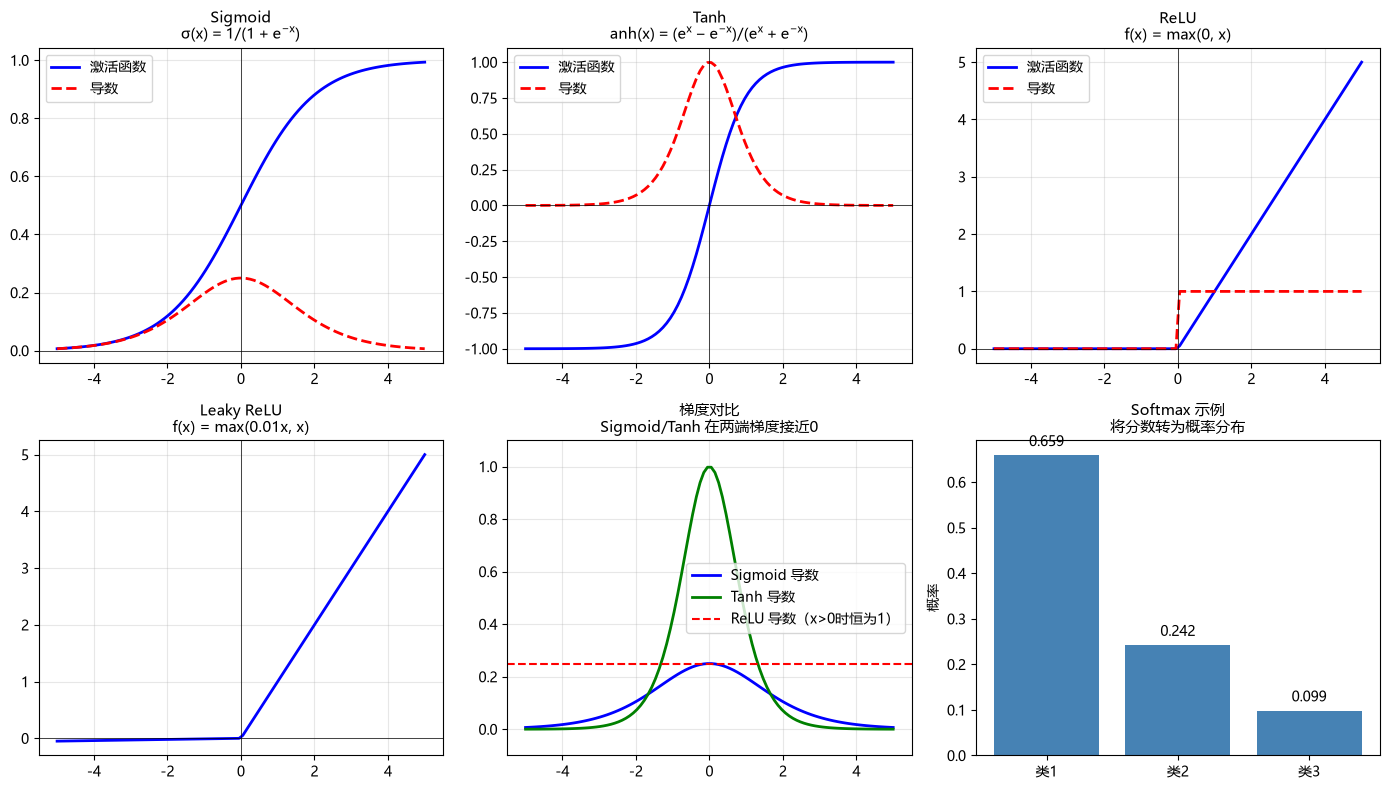


💡 观察要点：
  1. Sigmoid/Tanh 的导数在两端接近 0（梯度消失！）
  2. ReLU 的导数在正区间恒为 1（梯度不会消失）
  3. Leaky ReLU 解决了 ReLU 的'神经元死亡'问题
  4. Softmax 的输出是概率，所有概率和为 1


In [26]:
# 可视化各种激活函数
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

# 绘制激活函数
x = np.linspace(-5, 5, 100)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Sigmoid
axes[0, 0].plot(x, sigmoid(x), 'b-', linewidth=2)
axes[0, 0].plot(x, sigmoid_derivative(x), 'r--', linewidth=2)
axes[0, 0].set_title('Sigmoid\n$\sigma(x) = 1/(1+e^{-x})$', fontsize=11)
axes[0, 0].legend(['激活函数', '导数'])
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0, 0].axvline(x=0, color='k', linestyle='-', linewidth=0.5)

# Tanh
axes[0, 1].plot(x, tanh(x), 'b-', linewidth=2)
axes[0, 1].plot(x, 1 - tanh(x)**2, 'r--', linewidth=2)
axes[0, 1].set_title('Tanh\n$\tanh(x) = (e^x-e^{-x})/(e^x+e^{-x})$', fontsize=11)
axes[0, 1].legend(['激活函数', '导数'])
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0, 1].axvline(x=0, color='k', linestyle='-', linewidth=0.5)

# ReLU
axes[0, 2].plot(x, relu(x), 'b-', linewidth=2)
axes[0, 2].plot(x, relu_derivative(x), 'r--', linewidth=2)
axes[0, 2].set_title('ReLU\nf(x) = max(0, x)', fontsize=11)
axes[0, 2].legend(['激活函数', '导数'])
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0, 2].axvline(x=0, color='k', linestyle='-', linewidth=0.5)

# Leaky ReLU
axes[1, 0].plot(x, leaky_relu(x), 'b-', linewidth=2)
axes[1, 0].set_title('Leaky ReLU\nf(x) = max(0.01x, x)', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 0].axvline(x=0, color='k', linestyle='-', linewidth=0.5)

# 对比：梯度消失问题
axes[1, 1].plot(x, sigmoid_derivative(x), 'b-', linewidth=2, label='Sigmoid 导数')
axes[1, 1].plot(x, 1 - tanh(x)**2, 'g-', linewidth=2, label='Tanh 导数')
axes[1, 1].axhline(y=0.25, color='r', linestyle='--', label='ReLU 导数（x>0时恒为1）')
axes[1, 1].set_title('梯度对比\nSigmoid/Tanh 在两端梯度接近0', fontsize=11)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(-0.1, 1.1)

# Softmax 示例
x_softmax = np.array([2.0, 1.0, 0.1])
exp_x = np.exp(x_softmax - np.max(x_softmax))  # 数值稳定
softmax_x = exp_x / np.sum(exp_x)
axes[1, 2].bar(['类1', '类2', '类3'], softmax_x, color='steelblue')
axes[1, 2].set_title('Softmax 示例\n将分数转为概率分布', fontsize=11)
axes[1, 2].set_ylabel('概率')
for i, v in enumerate(softmax_x):
    axes[1, 2].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

print("\n💡 观察要点：")
print("  1. Sigmoid/Tanh 的导数在两端接近 0（梯度消失！）")
print("  2. ReLU 的导数在正区间恒为 1（梯度不会消失）")
print("  3. Leaky ReLU 解决了 ReLU 的'神经元死亡'问题")
print("  4. Softmax 的输出是概率，所有概率和为 1")

---

## 第三部分：损失函数详解

### 3.1 为什么需要损失函数？

**💡 损失函数衡量"错了多少"**（吴恩达课程核心概念）：

损失函数 $L$ 的作用：
- 比较预测值 $\hat{y}$ 和真实值 $y$ 的差距
- 差距越大，损失越大
- 神经网络的**目标**是最小化损失函数

**神经网络的训练 = 找到一组合适的 (W, b)，让损失最小**

### 3.2 常用损失函数

| 损失函数 | 用途 | 公式 | 特点 |
|----------|------|------|------|
| **MSE** | 回归 | $L = \frac{1}{n}\sum(\hat{y} - y)^2$ | 二次惩罚，易优化 |
| **BCE** | 二分类 | $L = -[y\log\hat{y} + (1-y)\log(1-\hat{y})]$ | 概率输出 |
| **CEE** | 多分类 | $L = -\sum y_i \log(\hat{y}_i)$ | Softmax 配合 |

**💡 二分类交叉熵的直观理解**（吴恩达课程详解）：

当 $y=1$（正类）时：$L = -\log(\hat{y})$
- 如果 $\hat{y}=0.9$（预测接近1），损失很小
- 如果 $\hat{y}=0.1$（预测远离1），损失很大

当 $y=0$（负类）时：$L = -\log(1-\hat{y})$
- 如果 $\hat{y}=0.1$（预测接近0），损失很小
- 如果 $\hat{y}=0.9$（预测远离0），损失很大

**💡 交叉熵 vs MSE**：
- 交叉熵的梯度更稳定（不会因为 sigmoid 导数太小而梯度消失）
- 现代神经网络分类任务首选交叉熵

---

## 第四部分：反向传播详解 ⭐⭐⭐

### 4.1 反向传播的本质——链式法则

**💡 这是深度学习最重要的数学基础**（吴恩达+李宏毅课程重点）：

**链式法则**（微积分基础）：
$$\frac{dL}{dx} = \frac{dL}{dy} \cdot \frac{dy}{dx}$$

**反向传播的直观理解**：
```
想象你在一场考试中得了 60 分（损失函数的值）

你想提高成绩，需要找出哪道题丢分最多：
  - 数学题扣 10 分
  - 英语题扣 20 分  ← 英语丢分最多，应该多花时间！
  - 物理题扣 10 分

反向传播就是这样：
- 从输出层开始
- 逐层分析每个参数对损失的"贡献"
- 贡献大的参数需要大幅调整
```

### 4.2 单层神经网络的梯度计算

以最简单的单层网络为例（吴恩达课程）：

```
输入 x → [线性变换] → z = wx + b → [激活] → a = σ(z) → [损失] → L
```

**前向传播**：
$$z = wx + b$$
$$a = \sigma(z)$$
$$L = \frac{1}{2}(a - y)^2$$

**反向传播（求 $\frac{\partial L}{\partial w}$ 和 $\frac{\partial L}{\partial b}$）**：

Step 1: $\frac{\partial L}{\partial a} = a - y$（损失对输出的梯度）

Step 2: $\frac{\partial a}{\partial z} = \sigma'(z) = a(1-a)$（激活函数的梯度）

Step 3: $\frac{\partial z}{\partial w} = x$（线性变换的梯度）

Step 4（链式法则）：
$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w}$$
$$= (a - y) \cdot a(1-a) \cdot x$$

**💡 梯度流向**：$L \rightarrow a \rightarrow z \rightarrow w$

In [27]:
# 用具体数字演示单层网络的梯度计算
import numpy as np

# 假设
w = 0.5      # 权重
b = 0.1      # 偏置
x = 2.0      # 输入
y = 1.0      # 真实标签

print("=" * 60)
print("单层神经网络梯度计算演示")
print("=" * 60)

print(f"\n【前向传播】")
print(f"  输入: x = {x}")
print(f"  权重: w = {w}")
print(f"  偏置: b = {b}")

# 前向传播
z = w * x + b
a = 1 / (1 + np.exp(-z))  # Sigmoid
loss = 0.5 * (a - y) ** 2

print(f"\n  z = wx + b = {w}*{x} + {b} = {z:.4f}")
print(f"  a = sigmoid(z) = {a:.4f}")
print(f"  L = 0.5*(a-y)^2 = {loss:.4f}")

print(f"\n【反向传播】")
print(f"  真实标签: y = {y}")

# 反向传播
d_loss_d_a = a - y  # ∂L/∂a
d_a_d_z = a * (1 - a)  # ∂a/∂z = sigmoid(z)(1-sigmoid(z))
d_z_d_w = x  # ∂z/∂w
d_z_d_b = 1  # ∂z/∂b

print(f"\n  Step 1: ∂L/∂a = a - y = {a:.4f} - {y} = {d_loss_d_a:.4f}")
print(f"\n  Step 2: ∂a/∂z = a(1-a) = {a:.4f}*(1-{a:.4f}) = {d_a_d_z:.4f}")
print(f"  （Sigmoid 的导数公式）")

# 链式法则
d_loss_d_w = d_loss_d_a * d_a_d_z * d_z_d_w
d_loss_d_b = d_loss_d_a * d_a_d_z * d_z_d_b

print(f"\n  Step 3: ∂L/∂w = ∂L/∂a × ∂a/∂z × ∂z/∂w")
print(f"         = {d_loss_d_a:.4f} × {d_a_d_z:.4f} × {d_z_d_w:.4f}")
print(f"         = {d_loss_d_w:.4f}")

print(f"\n  Step 4: ∂L/∂b = ∂L/∂a × ∂a/∂z × ∂z/∂b")
print(f"         = {d_loss_d_a:.4f} × {d_a_d_z:.4f} × {d_z_d_b}")
print(f"         = {d_loss_d_b:.4f}")

# 梯度验证（数值梯度）
epsilon = 1e-5
w_plus = w + epsilon
z_plus = w_plus * x + b
a_plus = 1 / (1 + np.exp(-z_plus))
loss_plus = 0.5 * (a_plus - y) ** 2
numerical_grad_w = (loss_plus - loss) / epsilon

print(f"\n【梯度验证】")
print(f"  解析梯度: ∂L/∂w = {d_loss_d_w:.6f}")
print(f"  数值梯度: ≈ {numerical_grad_w:.6f}")
print(f"  误差: {abs(d_loss_d_w - numerical_grad_w):.10f}")
print(f"\n  ✓ 两者非常接近，证明梯度计算正确！")

单层神经网络梯度计算演示

【前向传播】
  输入: x = 2.0
  权重: w = 0.5
  偏置: b = 0.1

  z = wx + b = 0.5*2.0 + 0.1 = 1.1000
  a = sigmoid(z) = 0.7503
  L = 0.5*(a-y)^2 = 0.0312

【反向传播】
  真实标签: y = 1.0

  Step 1: ∂L/∂a = a - y = 0.7503 - 1.0 = -0.2497

  Step 2: ∂a/∂z = a(1-a) = 0.7503*(1-0.7503) = 0.1874
  （Sigmoid 的导数公式）

  Step 3: ∂L/∂w = ∂L/∂a × ∂a/∂z × ∂z/∂w
         = -0.2497 × 0.1874 × 2.0000
         = -0.0936

  Step 4: ∂L/∂b = ∂L/∂a × ∂a/∂z × ∂z/∂b
         = -0.2497 × 0.1874 × 1
         = -0.0468

【梯度验证】
  解析梯度: ∂L/∂w = -0.093587
  数值梯度: ≈ -0.093586
  误差: 0.0000011706

  ✓ 两者非常接近，证明梯度计算正确！


### 4.3 两层神经网络的梯度计算

**💡 这是实际神经网络的标准结构**（吴恩达课程核心）：

网络结构：
```
输入 x → 隐藏层 → 输出层 → 损失 L

前向传播：
  z1 = W1 @ x + b1     (隐藏层线性变换)
  a1 = sigmoid(z1)    (隐藏层激活)
  z2 = W2 @ a1 + b2    (输出层线性变换)
  a2 = sigmoid(z2)    (输出层激活)
  L = BCE(a2, y)      (损失)
```

**反向传播（链式法则的威力）**：

对输出层参数：
$$\frac{\partial L}{\partial a_2} \rightarrow \frac{\partial a_2}{\partial z_2} \rightarrow \frac{\partial z_2}{\partial W_2}$$

对隐藏层参数：
$$\frac{\partial L}{\partial a_2} \rightarrow \frac{\partial a_2}{\partial z_2} \rightarrow \frac{\partial z_2}{\partial a_1} \rightarrow \frac{\partial a_1}{\partial z_1} \rightarrow \frac{\partial z_1}{\partial W_1}$$

**💡 梯度逐层回传，每层只算自己的局部梯度**

---

## 第五部分：纯 NumPy 手撕神经网络

### 5.1 实现激活函数及其导数

**💡 动手实现是理解神经网络的最好方式**（Andrej Karpathy 课程理念）

In [28]:
import numpy as np

# ============ 激活函数 ============

def sigmoid(z):
    """
    Sigmoid 函数: σ(z) = 1 / (1 + e^(-z))
    
    特点:
    - 输出范围 [0, 1]
    - 适合二分类问题
    - 缺点: 梯度在两端接近0（梯度消失）
    """
    # 数值稳定处理：减去最大值避免溢出
    z_safe = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z_safe))

def sigmoid_derivative(a):
    """
    Sigmoid 的导数: σ'(z) = σ(z) * (1 - σ(z))
    
    注意: 输入是激活值 a = sigmoid(z)，不是 z 本身！
    这就是为什么前向传播要保存 a 值
    """
    return a * (1 - a)

def relu(z):
    """
    ReLU 函数: max(0, z)
    
    特点:
    - 计算快
    - 正区间梯度恒为1
    - 现代深度学习首选
    """
    return np.maximum(0, z)

def relu_derivative(z):
    """
    ReLU 的导数:
    - z > 0: 导数 = 1
    - z <= 0: 导数 = 0
    
    注意: 这里输入是 z，不是激活值 a
    """
    return (z > 0).astype(np.float32)

def tanh(z):
    """
    Tanh 函数: (e^z - e^(-z)) / (e^z + e^(-z))
    
    特点:
    - 输出范围 [-1, 1]
    - 零中心
    - 梯度比 Sigmoid 更好
    """
    return np.tanh(z)

def tanh_derivative(a):
    """
    Tanh 的导数: tanh'(z) = 1 - tanh^2(z)
    
    注意: 输入是激活值 a = tanh(z)
    """
    return 1 - a ** 2

def softmax(z):
    """
    Softmax 函数: e^z / sum(e^z)
    
    特点:
    - 多分类输出
    - 输出是概率分布（和为1）
    - 数值稳定版本
    """
    # 减去最大值避免数值溢出
    z_safe = z - np.max(z, axis=-1, keepdims=True)
    exp_z = np.exp(z_safe)
    return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

# 测试激活函数
print("=" * 60)
print("激活函数测试")
print("=" * 60)

z_test = np.array([-2, -1, 0, 1, 2])

print(f"\n输入: {z_test}")
print(f"\nSigmoid: {sigmoid(z_test).round(4)}")
print(f"Tanh:    {tanh(z_test).round(4)}")
print(f"ReLU:    {relu(z_test)}")

# Softmax 测试（多分类）
z_multi = np.array([[1, 2, 3], [4, 5, 6]])
print(f"\n多分类 Softmax 输入:\n{z_multi}")
print(f"Softmax 输出:\n{softmax(z_multi).round(4)}")
print(f"验证（每行和为1）: {softmax(z_multi).sum(axis=1)}")

激活函数测试

输入: [-2 -1  0  1  2]

Sigmoid: [0.1192 0.2689 0.5    0.7311 0.8808]
Tanh:    [-0.964  -0.7616  0.      0.7616  0.964 ]
ReLU:    [0 0 0 1 2]

多分类 Softmax 输入:
[[1 2 3]
 [4 5 6]]
Softmax 输出:
[[0.09   0.2447 0.6652]
 [0.09   0.2447 0.6652]]
验证（每行和为1）: [1. 1.]


### 5.2 实现两层神经网络类

**💡 完整实现：前向传播 + 反向传播 + 训练**（Andrej Karpathy 风格）

In [ ]:
class NeuralNetwork:
    """
    两层全连接神经网络
    
    结构: 输入层 → 隐藏层(ReLU) → 输出层(Sigmoid) → 二分类
    
    参数:
        input_size: 输入特征维度
        hidden_size: 隐藏层神经元数量
        output_size: 输出维度（通常为1）
    """  # noqa: W293

    def __init__(self, input_size, hidden_size, output_size):
        """
        初始化神经网络

        使用 He 初始化权重（适合 ReLU 激活函数）
        """
        # 设置随机种子，确保可复现
        np.random.seed(42)

        # He 初始化: 权重 ~ N(0, sqrt(2/n_in))
        # 这种初始化适合 ReLU 激活函数
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))

        print(f"网络结构: {input_size} -> {hidden_size} -> {output_size}")
        print(f"参数量: {input_size*hidden_size + hidden_size + hidden_size*output_size + output_size}")

    def forward(self, X):
        """
        前向传播

        参数:
            X: 输入数据 (batch_size, input_size)

        返回:
            y_pred: 预测输出 (batch_size, output_size)
        """
        # 保存中间值，用于反向传播
        self.X = X

        # ===== 隐藏层 =====
        # 线性变换: z1 = X @ W1 + b1
        self.z1 = X @ self.W1 + self.b1
        # 激活函数: a1 = ReLU(z1)
        self.a1 = relu(self.z1)

        # ===== 输出层 =====
        # 线性变换: z2 = a1 @ W2 + b2
        self.z2 = self.a1 @ self.W2 + self.b2
        # 激活函数: a2 = sigmoid(z2)（二分类）
        self.a2 = sigmoid(self.z2)

        return self.a2

    def backward(self, y, y_pred, learning_rate):
        """
        反向传播

        参数:
            y: 真实标签 (batch_size, output_size)
            y_pred: 预测输出 (batch_size, output_size)
            learning_rate: 学习率
        """
        batch_size = self.X.shape[0]

        # ===== 输出层的梯度 =====
        # dL/da2: 损失对激活值的梯度
        # 使用交叉熵损失的梯度: dL/da2 = (a2 - y) / (a2(1-a2))
        # 对于 MSE: dL/da2 = a2 - y
        d_a2 = (y_pred - y) / batch_size

        # da2/dz2: Sigmoid 的梯度
        d_z2 = d_a2 * sigmoid_derivative(y_pred)

        # dz2/dW2 = a1, dz2/db2 = 1
        d_W2 = self.a1.T @ d_z2
        d_b2 = np.sum(d_z2, axis=0, keepdims=True)

        # ===== 隐藏层的梯度 =====
        # 从输出层传回来的梯度: d_z2 @ W2^T
        d_a1 = d_z2 @ self.W2.T

        # da1/dz1: ReLU 的梯度
        d_z1 = d_a1 * relu_derivative(self.z1)

        # dz1/dW1 = X, dz1/db1 = 1
        d_W1 = self.X.T @ d_z1
        d_b1 = np.sum(d_z1, axis=0, keepdims=True)

        # ===== 梯度裁剪（防止梯度爆炸）=====
        max_grad = 5.0
        d_W1 = np.clip(d_W1, -max_grad, max_grad)
        d_W2 = np.clip(d_W2, -max_grad, max_grad)

        # ===== 更新参数（梯度下降）=====
        self.W1 -= learning_rate * d_W1
        self.b1 -= learning_rate * d_b1
        self.W2 -= learning_rate * d_W2
        self.b2 -= learning_rate * d_b2

    def train(self, X, y, epochs, learning_rate, verbose=True):
        """
        训练神经网络

        参数:
            X: 训练数据
            y: 训练标签
            epochs: 训练轮数
            learning_rate: 学习率
            verbose: 是否打印训练过程
        """
        losses = []

        for epoch in range(epochs):
            # 前向传播
            y_pred = self.forward(X)

            # 计算损失（MSE）
            loss = np.mean((y_pred - y) ** 2)
            losses.append(loss)

            # 反向传播
            self.backward(y, y_pred, learning_rate)

            if verbose and (epoch + 1) % 1000 == 0:
                acc = self.evaluate(X, y)
                print(f"Epoch [{epoch+1:4d}/{epochs}]  Loss: {loss:.6f}  Acc: {acc:.2%}")

        return losses

    def predict(self, X):
        """预测（返回类别）"""
        y_pred = self.forward(X)
        return (y_pred > 0.5).astype(int)

    def evaluate(self, X, y):
        """评估准确率"""
        y_pred = self.predict(X)
        y_true = (y > 0.5).astype(int)
        return np.mean(y_pred == y_true)

print("\n✅ NeuralNetwork 类定义完成！")


✅ NeuralNetwork 类定义完成！


### 5.3 XOR 问题实战

**💡 XOR 是理解神经网络非线性的经典案例**（吴恩达课程必讲）：

单层感知机无法解决 XOR，但两层神经网络可以！

XOR 问题实战

XOR 数据集:
  (0, 0) -> 0
  (0, 1) -> 1
  (1, 0) -> 1
  (1, 1) -> 0

【训练】
网络结构: 2 -> 4 -> 1
参数量: 17
Epoch [1000/10000]  Loss: 0.009364  Acc: 100.00%
Epoch [2000/10000]  Loss: 0.002428  Acc: 100.00%
Epoch [3000/10000]  Loss: 0.001298  Acc: 100.00%
Epoch [4000/10000]  Loss: 0.000866  Acc: 100.00%
Epoch [5000/10000]  Loss: 0.000643  Acc: 100.00%
Epoch [6000/10000]  Loss: 0.000508  Acc: 100.00%
Epoch [7000/10000]  Loss: 0.000418  Acc: 100.00%
Epoch [8000/10000]  Loss: 0.000355  Acc: 100.00%
Epoch [9000/10000]  Loss: 0.000307  Acc: 100.00%
Epoch [10000/10000]  Loss: 0.000271  Acc: 100.00%

【测试结果】
  (0, 0): 预测=0.0262 (0), 真实=0 ✓
  (0, 1): 预测=0.9879 (1), 真实=1 ✓
  (1, 0): 预测=0.9879 (1), 真实=1 ✓
  (1, 1): 预测=0.0102 (0), 真实=0 ✓


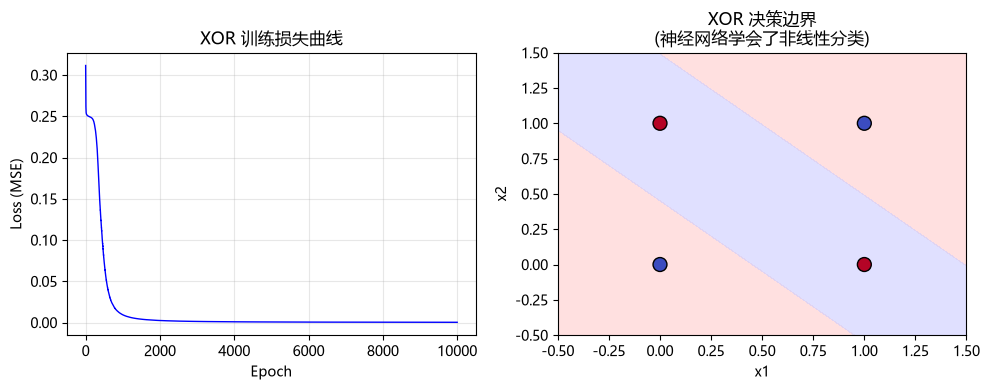


💡 观察：
  1. 损失逐渐下降，说明网络在学习
  2. 决策边界是非线性的，能够分开 (0,0)/(1,1) 和 (0,1)/(1,0)
  3. 这证明了两层神经网络可以解决 XOR 问题


In [30]:
print("=" * 60)
print("XOR 问题实战")
print("=" * 60)

# XOR 数据集
# 这是经典的非线性可分问题
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_xor = np.array([
    [0],  # 0 XOR 0 = 0
    [1],  # 0 XOR 1 = 1
    [1],  # 1 XOR 0 = 1
    [0]    # 1 XOR 1 = 0
])

print("\nXOR 数据集:")
for i in range(len(X_xor)):
    print(f"  ({X_xor[i, 0]}, {X_xor[i, 1]}) -> {y_xor[i][0]}")

# 创建并训练神经网络
print("\n【训练】")
nn_xor = NeuralNetwork(input_size=2, hidden_size=4, output_size=1)
losses = nn_xor.train(X_xor, y_xor, epochs=10000, learning_rate=0.5, verbose=True)

# 测试结果
print("\n【测试结果】")
y_pred = nn_xor.forward(X_xor)

for i in range(len(X_xor)):
    pred_class = 1 if y_pred[i, 0] > 0.5 else 0
    true_class = int(y_xor[i, 0])
    status = "✓" if pred_class == true_class else "✗"
    print(f"  ({X_xor[i, 0]}, {X_xor[i, 1]}): "
          f"预测={y_pred[i, 0]:.4f} ({pred_class}), "
          f"真实={true_class} {status}")

# 可视化训练过程
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses, 'b-', linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('XOR 训练损失曲线')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# 可视化决策边界
x1_range = np.linspace(-0.5, 1.5, 100)
x2_range = np.linspace(-0.5, 1.5, 100)
xx1, xx2 = np.meshgrid(x1_range, x2_range)

X_grid = np.c_[xx1.ravel(), xx2.ravel()]
y_grid = nn_xor.forward(X_grid).reshape(xx1.shape)

plt.contourf(xx1, xx2, y_grid, levels=[0, 0.5, 1], colors=['#FFCCCC', '#CCCCFF'], alpha=0.6)
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor.ravel(), edgecolors='black', s=100, cmap='coolwarm')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('XOR 决策边界\n(神经网络学会了非线性分类)')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)

plt.tight_layout()
plt.show()

print("\n💡 观察：")
print("  1. 损失逐渐下降，说明网络在学习")
print("  2. 决策边界是非线性的，能够分开 (0,0)/(1,1) 和 (0,1)/(1,0)")
print("  3. 这证明了两层神经网络可以解决 XOR 问题")

### 5.4 MNIST 手写数字识别实战

**💡 这是深度学习的 Hello World**（吴恩达+李宏毅课程标准实战）：

MNIST 数据集包含 0-9 的手写数字图片

MNIST 手写数字识别实战

正在加载 MNIST 数据集...
(首次运行会自动下载，使用国内镜像源加速)


100%|██████████| 9.91M/9.91M [03:42<00:00, 44.5kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 111kB/s]
100%|██████████| 1.65M/1.65M [01:59<00:00, 13.8kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.54MB/s]


原始数据集: 训练 (60000, 784), 测试 (10000, 784)
训练集: (2000, 784)
测试集: (500, 784)
正样本（数字5）比例: 9.00%


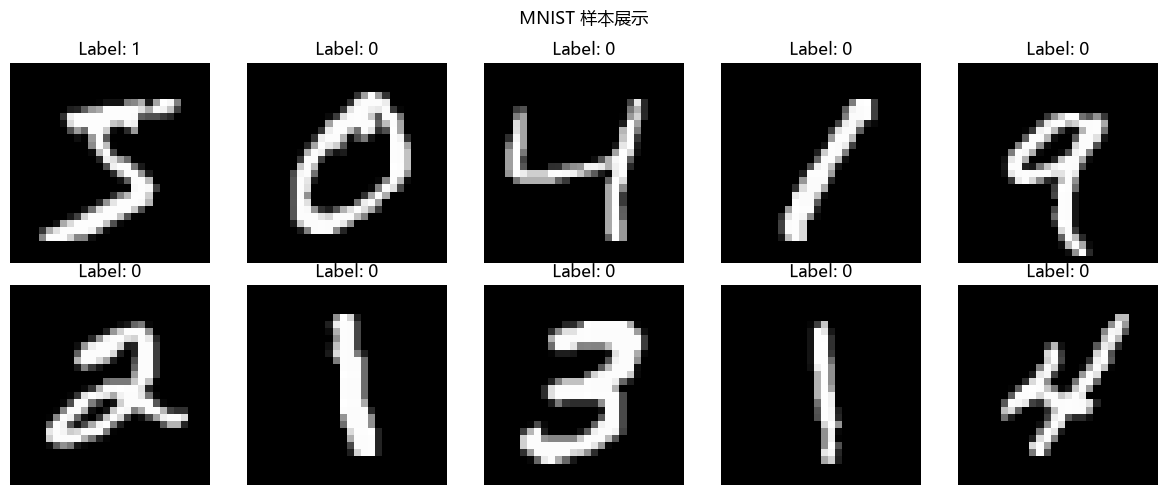

In [32]:
# MNIST 数据集加载（使用 PyTorch torchvision，速度更快）
import torchvision
from torchvision import datasets
import os

print("=" * 60)
print("MNIST 手写数字识别实战")
print("=" * 60)

# 数据目录（会自动下载到此目录）
data_dir = os.path.expanduser('~/.torchvision_data')
os.makedirs(data_dir, exist_ok=True)

print("\n正在加载 MNIST 数据集...")
print("(首次运行会自动下载，使用国内镜像源加速)")

# 使用 torchvision 加载 MNIST（比 sklearn 快得多）
train_dataset = datasets.MNIST(
    root=data_dir,
    train=True,
    download=True,
    transform=None  # 保持原始格式
)
test_dataset = datasets.MNIST(
    root=data_dir,
    train=False,
    download=True,
    transform=None
)

# 提取数据和标签
X_train_all = train_dataset.data.numpy().reshape(-1, 784) / 255.0
y_train_all = train_dataset.targets.numpy()
X_test_all = test_dataset.data.numpy().reshape(-1, 784) / 255.0
y_test_all = test_dataset.targets.numpy()

print(f"原始数据集: 训练 {X_train_all.shape}, 测试 {X_test_all.shape}")

# 二分类：检测是否为数字 5
y_train_binary = (y_train_all == 5).astype(np.float32).reshape(-1, 1)
y_test_binary = (y_test_all == 5).astype(np.float32).reshape(-1, 1)

# 为了快速演示，只用少量样本
n_train = 2000
n_test = 500
X_train = X_train_all[:n_train]
y_train = y_train_binary[:n_train]
X_test = X_test_all[:n_test]
y_test = y_test_binary[:n_test]

print(f"训练集: {X_train.shape}")
print(f"测试集: {X_test.shape}")
print(f"正样本（数字5）比例: {y_train.mean():.2%}")

# 可视化一些样本
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {int(y_train[i, 0])}')
    ax.axis('off')
plt.suptitle('MNIST 样本展示')
plt.tight_layout()
plt.show()


【训练神经网络】
(这可能需要几分钟...)

网络结构: 784 -> 128 -> 1
参数量: 100609
Epoch [1000/3000]  Loss: 0.023670  Acc: 97.85%
Epoch [2000/3000]  Loss: 0.014512  Acc: 98.85%
Epoch [3000/3000]  Loss: 0.009968  Acc: 99.20%

【最终结果】
  训练准确率: 99.20%
  测试准确率: 96.40%


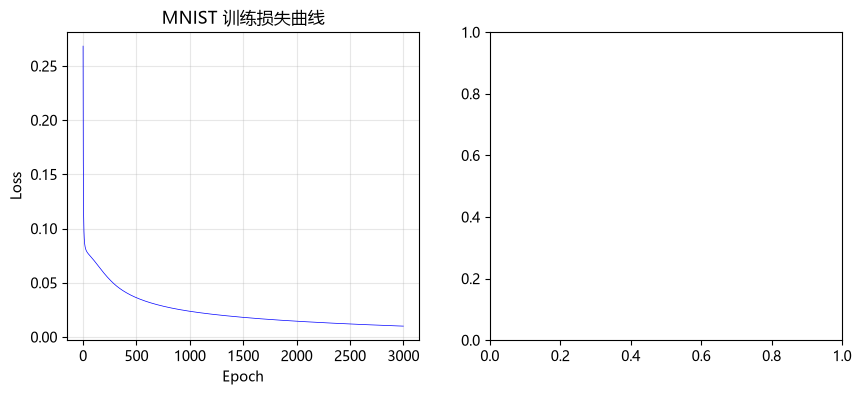

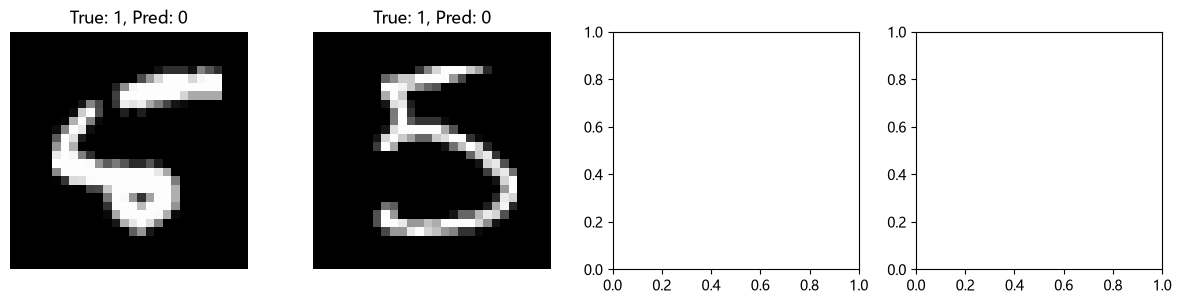

In [33]:
# 训练神经网络
print("\n【训练神经网络】")
print("(这可能需要几分钟...)\n")

# 使用更大的隐藏层
nn_mnist = NeuralNetwork(input_size=784, hidden_size=128, output_size=1)

# 训练
losses = nn_mnist.train(X_train, y_train, epochs=3000, learning_rate=0.1, verbose=True)

# 评估
train_acc = nn_mnist.evaluate(X_train, y_train)
test_acc = nn_mnist.evaluate(X_test, y_test)

print(f"\n【最终结果】")
print(f"  训练准确率: {train_acc:.2%}")
print(f"  测试准确率: {test_acc:.2%}")

# 可视化训练曲线
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses, 'b-', linewidth=0.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MNIST 训练损失曲线')
plt.grid(True, alpha=0.3)

# 展示一些预测结果
plt.subplot(1, 2, 2)
y_pred_test = nn_mnist.forward(X_test)

# 找出一些正确和错误的预测
correct_mask = ((y_pred_test > 0.5).astype(int) == y_test.astype(int)).flatten()
incorrect_mask = ~correct_mask

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, mask, label in zip(axes, [correct_mask, incorrect_mask], ['Correct', 'Incorrect']):
    indices = np.where(mask)[0][:2]
    for i, idx in enumerate(indices):
        ax_i = axes[i] if i < 2 else None
        if ax_i:
            ax_i.imshow(X_test[idx].reshape(28, 28), cmap='gray')
            pred = 1 if y_pred_test[idx, 0] > 0.5 else 0
            ax_i.set_title(f'True: {int(y_test[idx, 0])}, Pred: {pred}')
            ax_i.axis('off')

plt.tight_layout()
plt.show()

---

## 第六部分：对比 PyTorch 实现

### 6.1 PyTorch 实现的优势

**💡 理解手写 vs 框架的关系**（吴恩达课程理念）：

- **手写实现**：帮助你理解底层原理
- **PyTorch 实现**：提高开发效率，用于实际项目

**两者都很重要！**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

print("=" * 60)
print("PyTorch 实现对比")
print("=" * 60)

class PyTorchNN(nn.Module):
    """
    用 PyTorch 实现的等价神经网络
    """
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# 创建模型
pt_model = PyTorchNN(input_size=784, hidden_size=128, output_size=1)

# 损失函数和优化器
criterion = nn.BCELoss()  # PyTorch 内置的二元交叉熵
optimizer = optim.SGD(pt_model.parameters(), lr=0.1)

print(f"\nPyTorch 模型结构:")
print(pt_model)

# 转换为 Tensor
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# 训练
print("\n【PyTorch 训练】")
n_epochs = 3000

for epoch in range(n_epochs):
    pt_model.train()

    # ① 前向传播（PyTorch 自动计算图）
    y_pred = pt_model(X_train_tensor)

    # ② 计算损失
    loss = criterion(y_pred, y_train_tensor)

    # ③ 清零梯度
    optimizer.zero_grad()

    # ④ 反向传播（一行代码！）
    loss.backward()

    # ⑤ 更新参数
    optimizer.step()

    if (epoch + 1) % 1000 == 0:
        print(f"Epoch [{epoch+1:4d}/{n_epochs}]  Loss: {loss.item():.6f}")

# 评估
pt_model.eval()
with torch.no_grad():
    y_pred_pt = pt_model(X_test_tensor).numpy()
    predictions_pt = (y_pred_pt > 0.5).astype(int)
    accuracy_pt = (predictions_pt == y_test.astype(int)).mean()

print(f"\n【PyTorch 结果】")
print(f"  测试准确率: {accuracy_pt:.2%}")

PyTorch 实现对比

PyTorch 模型结构:
PyTorchNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

【PyTorch 训练】
Epoch [1000/3000]  Loss: 0.031094
Epoch [2000/3000]  Loss: 0.010081
Epoch [3000/3000]  Loss: 0.004764

【PyTorch 结果】
  测试准确率: 97.20%


### 6.2 手写 vs PyTorch 对比总结

| 方面 | NumPy 手写 | PyTorch |
|------|-----------|---------|
| **前向传播** | 手动计算矩阵乘法 | `model(x)` 自动 |
| **反向传播** | 手动推导链式法则 | `loss.backward()` 自动 |
| **参数更新** | 手动 W -= lr * dW | `optimizer.step()` 自动 |
| **GPU 加速** | 不支持 | `.to('cuda')` 一行 |
| **自动求导** | 不支持 | PyTorch 核心功能 |
| **代码量** | 多（需实现所有细节） | 少（框架封装） |
| **学习价值** | 高（理解底层原理） | 高（实际开发用） |

**💡 正确的学习路径**（Andrej Karpathy 建议）：
1. 先用手写实现，理解每一步在做什么
2. 再用框架，看到它如何简化工作
3. 最终能用框架快速实现想法

---

## 第七部分：关键概念深入理解

### 7.1 权重初始化——为什么很重要？

**💡 初始化不当会导致训练失败**（李宏毅老师课程重点）：

**问题 1：全零初始化**
```
如果 W = 0：
- 所有隐藏层神经元学到相同的特征
- 相当于只有一个神经元在工作
- 模型表达能力大幅下降
```

**问题 2：过大/过小初始化**
```
过大: Sigmoid/Tanh 输出饱和，梯度消失
过小: 信号衰减，每层输出接近0，梯度消失
```

**解决方案：合适的初始化方法**

| 方法 | 适用场景 | 公式 |
|------|----------|------|
| **Xavier** | Sigmoid/Tanh | $W \sim \mathcal{N}(0, 1/n_{in})$ |
| **He** | ReLU | $W \sim \mathcal{N}(0, 2/n_{in})$ |
| **kaiming** | ReLU 变体 | 类似 He |

**💡 为什么 He 初始化适合 ReLU？**
因为 ReLU 会把一半的神经元输出设为 0，所以需要更大的方差来保持信号强度。

### 7.2 学习率——训练神经网络的关键超参数

**💡 学习率设置不当会导致训练失败**（吴恩达课程核心）：

**学习率太小的表现**：
- 损失下降非常慢
- 需要成千上万轮训练
- 容易陷入局部最优

**学习率太大的表现**：
- 损失可能不降反升
- 损失剧烈震荡
- 可能直接发散

**学习率合适的表现**：
- 损失平稳下降
- 最终收敛到一个较低的值

**实践建议**（吴恩达课程建议）：
1. 从 0.01 开始尝试
2. 观察 loss 曲线调整
3. 后期可以使用学习率衰减

```python
# 学习率衰减示例
learning_rate = 0.01 * (0.1 ** (epoch / epochs))
```

### 7.3 梯度消失和梯度爆炸

**💡 这是深层神经网络的主要训练困难**（吴恩达课程深入讲解）：

**梯度消失（Vanishing Gradient）**：
```
当梯度 < 1 时：
∂L/∂W1 = ∂L/∂a_n × ∂a_n/∂a_{n-1} × ... × ∂a_2/∂W1
        ≈ 0.01 × 0.01 × ... × 0.01  (多层连乘)
        ≈ 0  (梯度消失！)

后果：
- 靠近输入层的参数几乎不更新
- 网络难以训练深層结构
```

**梯度爆炸（Exploding Gradient）**：
```
当梯度 > 1 时：
∂L/∂W1 ≈ 2 × 2 × ... × 2  (多层连乘)
        ≈ 很大  (梯度爆炸！)

后果：
- 参数更新过大
- 损失可能变成 NaN
- 训练不稳定
```

**解决方案**：
1. **残差连接**（ResNet）：梯度有高速公路直达底层
2. **Batch Normalization**：归一化每一层的输入
3. **合适的初始化**：He 初始化
4. **梯度裁剪**：防止梯度爆炸

---

## 今日学习总结

### ✅ 核心知识点

| 概念 | 理解要点 |
|------|----------|
| **神经元** | 加权求和 + 激活函数 |
| **XOR 问题** | 单层无法解决，需要多层 |
| **前向传播** | 输入→隐藏→输出，逐步计算 |
| **激活函数** | 引入非线性，ReLU 是现代首选 |
| **损失函数** | 衡量预测与真实的差距 |
| **反向传播** | 链式法则，梯度逐层回传 |
| **梯度下降** | W = W - lr × ∂L/∂W |
| **权重初始化** | He 初始化适合 ReLU |
| **学习率** | 太大震荡，太小太慢 |
| **梯度问题** | 消失/爆炸，残差连接缓解 |

### 📚 推荐学习资源

1. **吴恩达 Deep Learning 专项课程**（Coursera）
   - Neural Networks and Deep Learning
   - Improving Deep Neural Networks
   
2. **李宏毅机器学习**（B站/YouTube）
   - 深度学习入门部分
   
3. **Andrej Karpathy**（YouTube）
   - Neural Networks Zero to Hero
   - 从零实现 GPT

### 🔜 下一步学习

明天我们将学习 Transformer 架构的宏观理解。